#**PROJECT OVERVIEW**

---

###a. Problem Statement

Fetal health assessment often relies on measurements obtained through cardiotocography (CTG), which records characteristics such as fetal heart rate, fetal movement, and uterine contractions.

Interpreting these measurements accurately is important because abnormal patterns may indicate that a fetus requires closer monitoring or further clinical assessment.

This project explores whether machine learning can learn patterns from CTG measurements and use them to classify fetal health status into different risk categories

###b. Objective

The objective of this project is to develop and evaluate machine learning models that can classify fetal health status using CTG measurements.

The project will investigate the data, identify useful predictive features, compare different classification algorithms, and determine which model provides the most reliable predictions.

###c. Why Does This Problem Matter?

Early identification of abnormal fetal conditions can help healthcare professionals provide closer monitoring and further assessment when needed. This project explores the potential of machine learning as a decision-support tool for fetal health assessment.

###d. What Are We Predicting?

We are predicting fetal health status using CTG measurements. The target has three classes:
1 — Normal
2 — Suspect
3 — Pathological
This makes the project a multiclass classification problem.

##1. Import Libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV

##2. Load Dataset.

In [ ]:
fetal_data = pd.read_csv("/content/fetal_health (1) (1).csv")
fetal_data

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


##3. Dataset Overview

In [ ]:
display(fetal_data.head())
display(fetal_data.info())
display(fetal_data.describe())
display(fetal_data.columns)
display(fetal_data.shape)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

None

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

(2126, 22)

####Findings

The dataset contains 2,126 observations and 22 columns.

It contains 21 CTG features and one target variable, fetal_health.

All columns are stored as float64 data types.

There are no missing values in the dataset.

The fetal_health variable is numerically encoded into three classes: Normal, Suspect, and Pathological.

##4. Exploratory Data Analysis.

###4.1 Feature Distribution.

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


,proportion
fetal_health,
1.0,77.845720
2.0,13.875823
3.0,8.278457


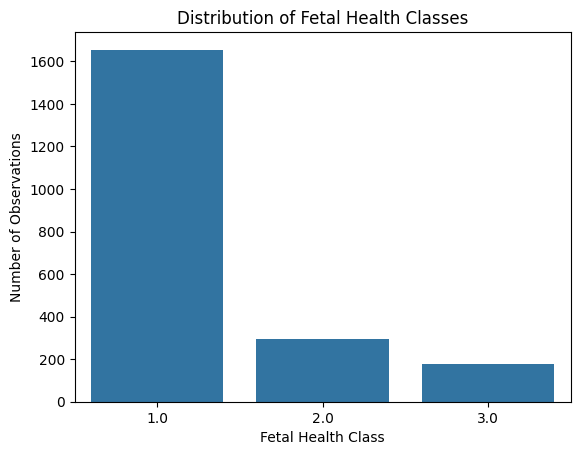

In [ ]:
class_counts = fetal_data["fetal_health"].value_counts()
class_proportion = fetal_data["fetal_health"].value_counts(normalize=True) * 100
display(class_counts)
display(class_proportion)

sns.barplot(x = class_counts.index, y = class_counts.values)
plt.xlabel("Fetal Health Class")
plt.ylabel("Number of Observations")
plt.title("Distribution of Fetal Health Classes")
plt.show()

####Findings

The dataset is highly imbalanced, with 77.85% of observations classified as Normal, compared with 13.88% Suspect and 8.28% Pathological.

The Pathological class is the least represented.

This class imbalance will be considered when selecting evaluation metrics and developing the classification models.

##4.2 Features Distribution

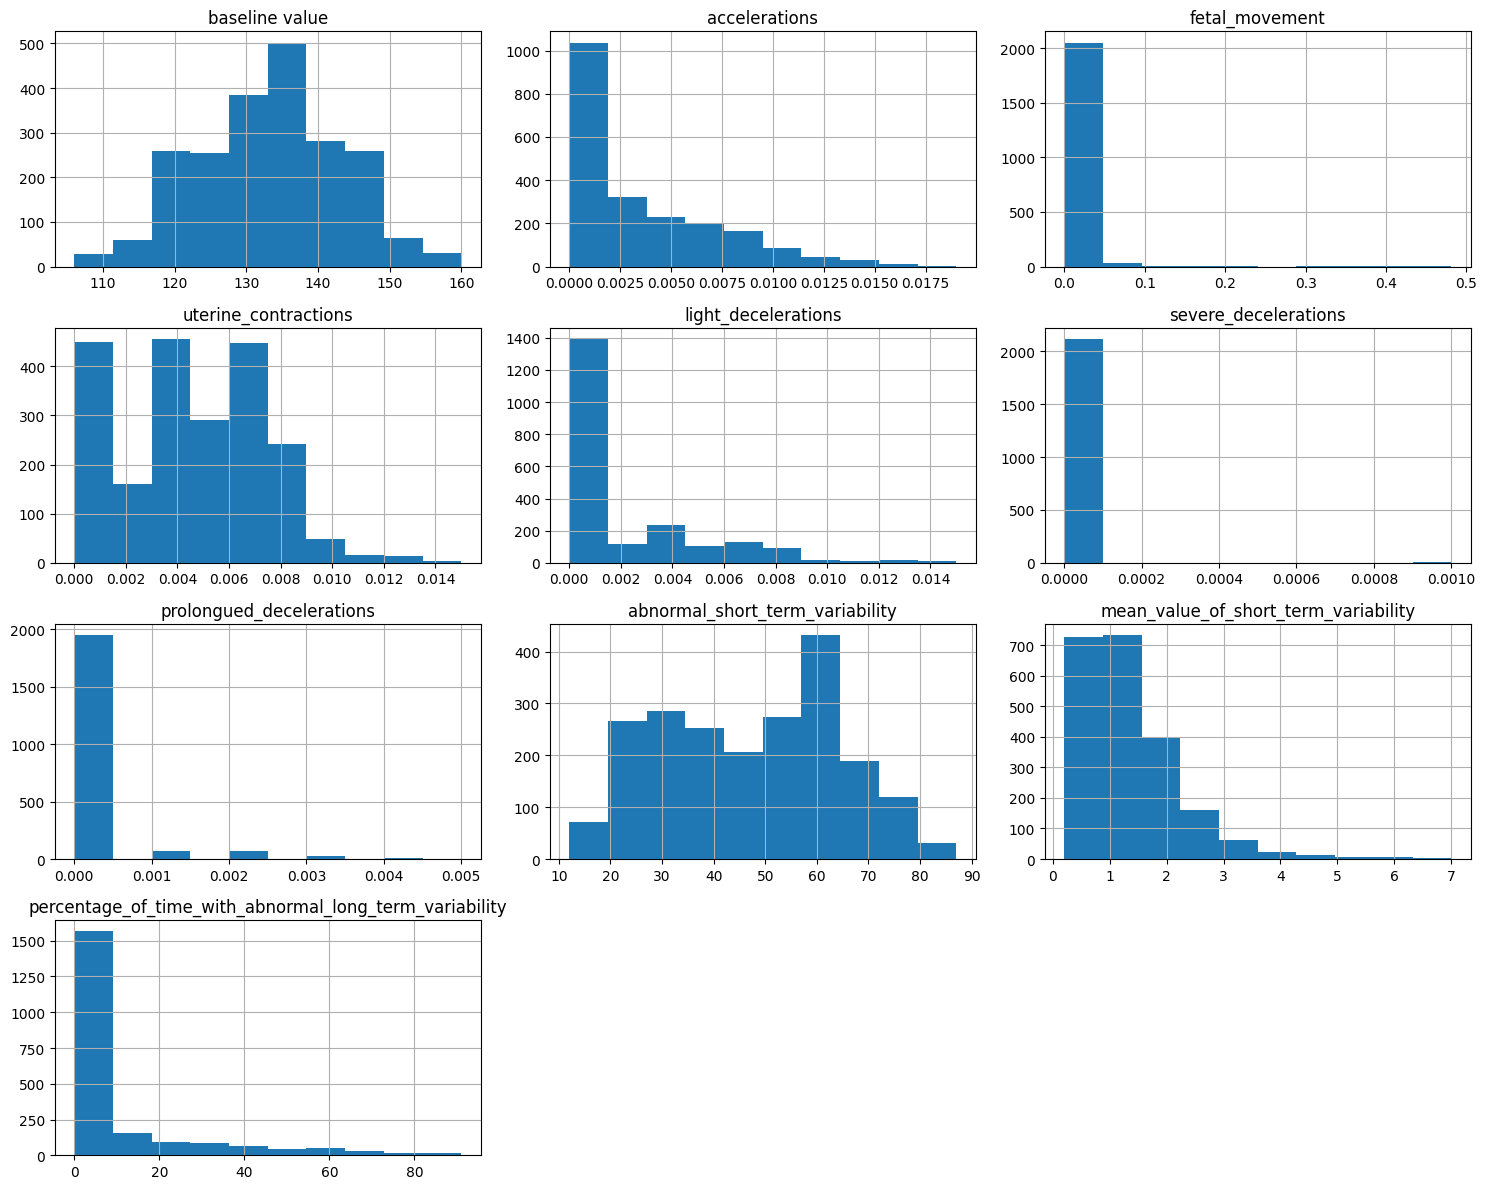

In [ ]:
features_1 = [
    "baseline value",
    "accelerations",
    "fetal_movement",
    "uterine_contractions",
    "light_decelerations",
    "severe_decelerations",
    "prolongued_decelerations",
    "abnormal_short_term_variability",
    "mean_value_of_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability"
]

fetal_data[features_1].hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

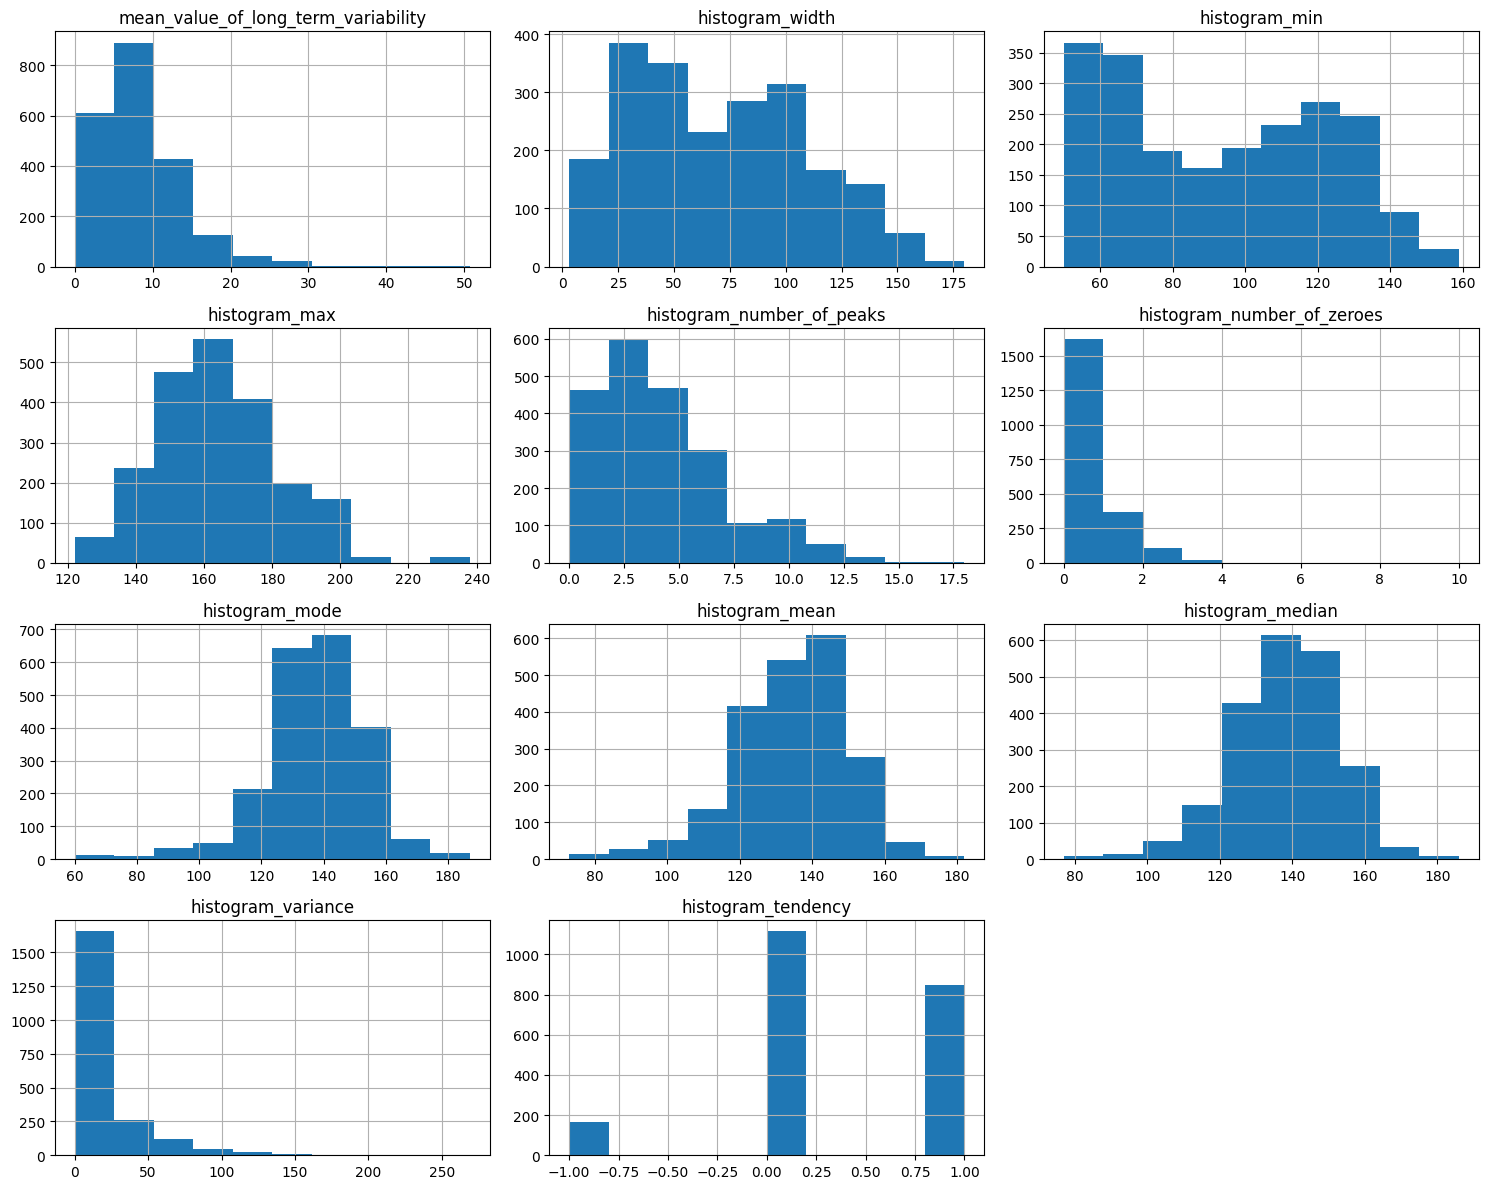

In [ ]:
features_2 = [
    "mean_value_of_long_term_variability",
    "histogram_width",
    "histogram_min",
    "histogram_max",
    "histogram_number_of_peaks",
    "histogram_number_of_zeroes",
    "histogram_mode",
    "histogram_mean",
    "histogram_median",
    "histogram_variance",
    "histogram_tendency"
]

fetal_data[features_2].hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

####Findings

The feature distributions vary considerably.
Several features, including accelerations, fetal_movement, light_decelerations, prolonged_decelerations, and histogram_variance, are strongly right-skewed, with most observations concentrated at lower values.

In contrast, features such as baseline_value, abnormal_short_term_variability, histogram_max, histogram_mode, histogram_mean, and histogram_median show approximately bell-shaped distributions.

Some features, particularly severe_decelerations and histogram_number_of_zeroes, are highly concentrated around zero, while histogram_width and histogram_min show relatively wider distributions.

Overall, the features exhibit different levels of concentration, spread, and distribution shape.

##4.3 Feature Distribution by Fetal Health Class

###4.3.1 Fetal heart-rate baseline & accelerations

a. What does the distribution of baseline values look like in each class?

b. Does the values of accelerations differ across the fetal health classes?

,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,131.981873,9.454513,106.0,125.0,132.0,138.0,160.0
2.0,295.0,141.684746,7.889044,120.0,137.0,143.0,147.0,159.0
3.0,176.0,131.687500,9.433016,110.0,128.0,132.0,134.0,152.0


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,0.003992,0.004001,0.0,0.0,0.003,0.007,0.019
2.0,295.0,0.000275,0.000726,0.0,0.0,0.000,0.000,0.005
3.0,176.0,0.000392,0.001008,0.0,0.0,0.000,0.000,0.005


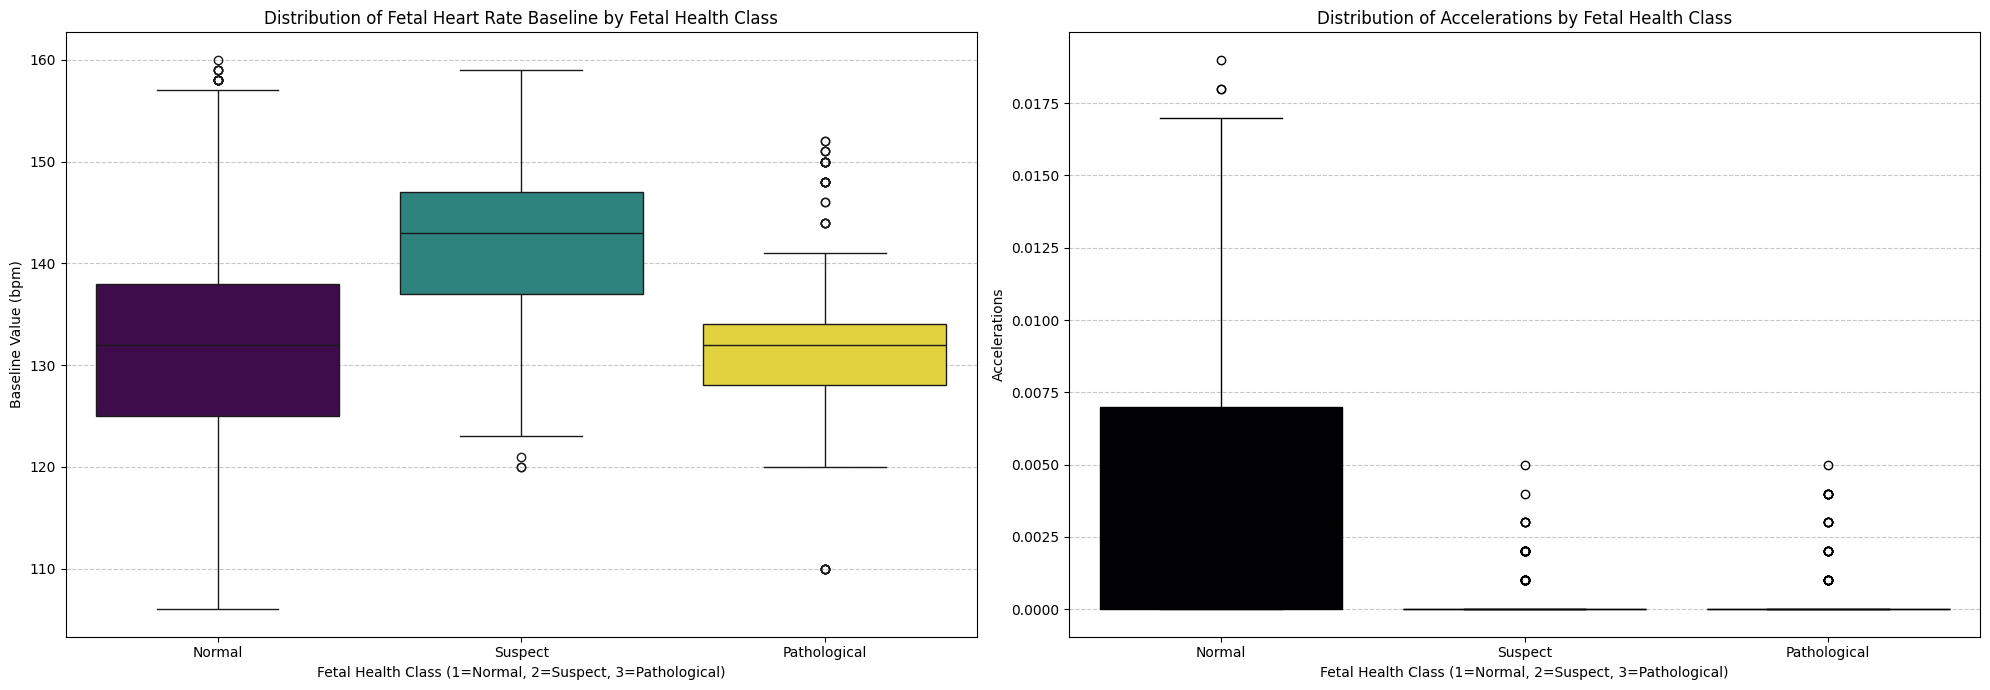

In [ ]:
baseline_dist = fetal_data.groupby("fetal_health")["baseline value"].describe()
acceleration_dist = fetal_data.groupby("fetal_health")["accelerations"]. describe()
display(baseline_dist)
display(acceleration_dist)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.boxplot(data=fetal_data, x="fetal_health", y="baseline value", palette="viridis", hue="fetal_health", legend=False, ax=axes[0])
axes[0].set_title("Distribution of Fetal Heart Rate Baseline by Fetal Health Class")
axes[0].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0].set_ylabel("Baseline Value (bpm)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])


sns.boxplot(data=fetal_data, x="fetal_health", y="accelerations", palette="magma", hue="fetal_health", legend=False, ax=axes[1])
axes[1].set_title("Distribution of Accelerations by Fetal Health Class")
axes[1].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[1].set_ylabel("Accelerations")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

plt.tight_layout()
plt.show()

####Findings

Baseline Value: Suspect cases had a notably higher mean baseline fetal heart rate (~141.7 bpm) compared with Normal (~132 bpm) and Pathological (~131.7 bpm) cases.

Accelerations: Normal cases showed substantially higher acceleration rates, while Suspect and Pathological cases had very low accelerations, with many observations showing no accelerations.

###4.2.2 Fetal movement & uterine activity

a. Does fetal movement differ across the fetal health classes?

b. Do uterine contractions differ across the fetal health classes?

,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,0.007963,0.040989,0.0,0.0,0.000,0.002,0.481
2.0,295.0,0.008332,0.041699,0.0,0.0,0.000,0.005,0.430
3.0,176.0,0.025676,0.085765,0.0,0.0,0.001,0.002,0.375


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,0.004781,0.002756,0.0,0.003,0.005,0.0070,0.015
2.0,295.0,0.002390,0.002660,0.0,0.000,0.001,0.0045,0.011
3.0,176.0,0.003784,0.003627,0.0,0.000,0.003,0.0060,0.014


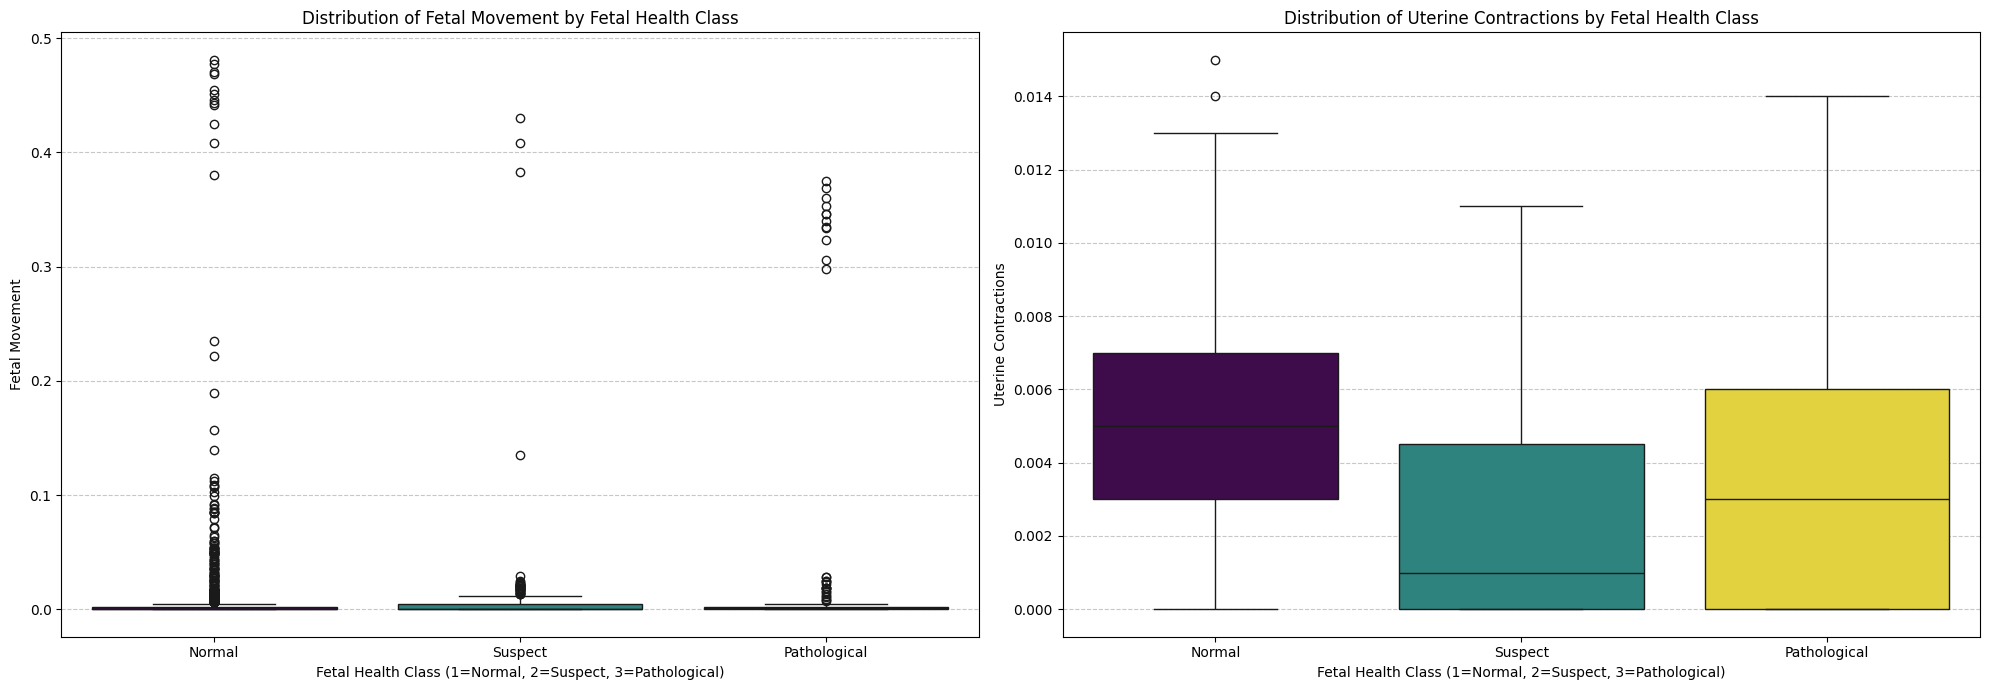

In [ ]:
fetal_movement_dist = fetal_data.groupby("fetal_health")["fetal_movement"].describe()
uterine_contractions_dist = fetal_data.groupby("fetal_health")["uterine_contractions"].describe()
display(fetal_movement_dist)
display(uterine_contractions_dist)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.boxplot(data=fetal_data, x="fetal_health", y="fetal_movement", palette="viridis", hue="fetal_health", legend=False, ax=axes[0])
axes[0].set_title("Distribution of Fetal Movement by Fetal Health Class")
axes[0].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0].set_ylabel("Fetal Movement")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

sns.boxplot(data=fetal_data, x="fetal_health", y="uterine_contractions", palette="viridis", hue="fetal_health", legend=False, ax=axes[1])
axes[1].set_title("Distribution of Uterine Contractions by Fetal Health Class")
axes[1].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[1].set_ylabel("Uterine Contractions")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

plt.tight_layout()
plt.show()

####Findings

Fetal Movement: Levels are consistently very low across all fetal health classes, with a large number of zero values and no strong differentiation evident between classes.

Uterine Contractions: Normal cases show slightly higher uterine contraction rates compared to suspect and pathological cases, but overall, there is limited distinct separation between the different fetal health classes for this feature.

###4.3.3 Fetal Health Deceleration Patterns.

a. Do light decelerations differ across fetal health classes?

b. Do severe decelerations differ across fetal health classes?

c. Do prolonged decelerations differ across fetal health classes?

,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,0.001941,0.002891,0.0,0.0,0.000,0.004,0.015
2.0,295.0,0.000536,0.001533,0.0,0.0,0.000,0.000,0.014
3.0,176.0,0.003670,0.004140,0.0,0.0,0.002,0.007,0.015


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,6.042296e-07,0.000025,0.0,0.0,0.0,0.0,0.001
2.0,295.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.000
3.0,176.0,3.409091e-05,0.000182,0.0,0.0,0.0,0.0,0.001


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,0.000051,0.000263,0.0,0.0,0.000,0.000,0.003
2.0,295.0,0.000095,0.000442,0.0,0.0,0.000,0.000,0.003
3.0,176.0,0.001273,0.001371,0.0,0.0,0.001,0.002,0.005


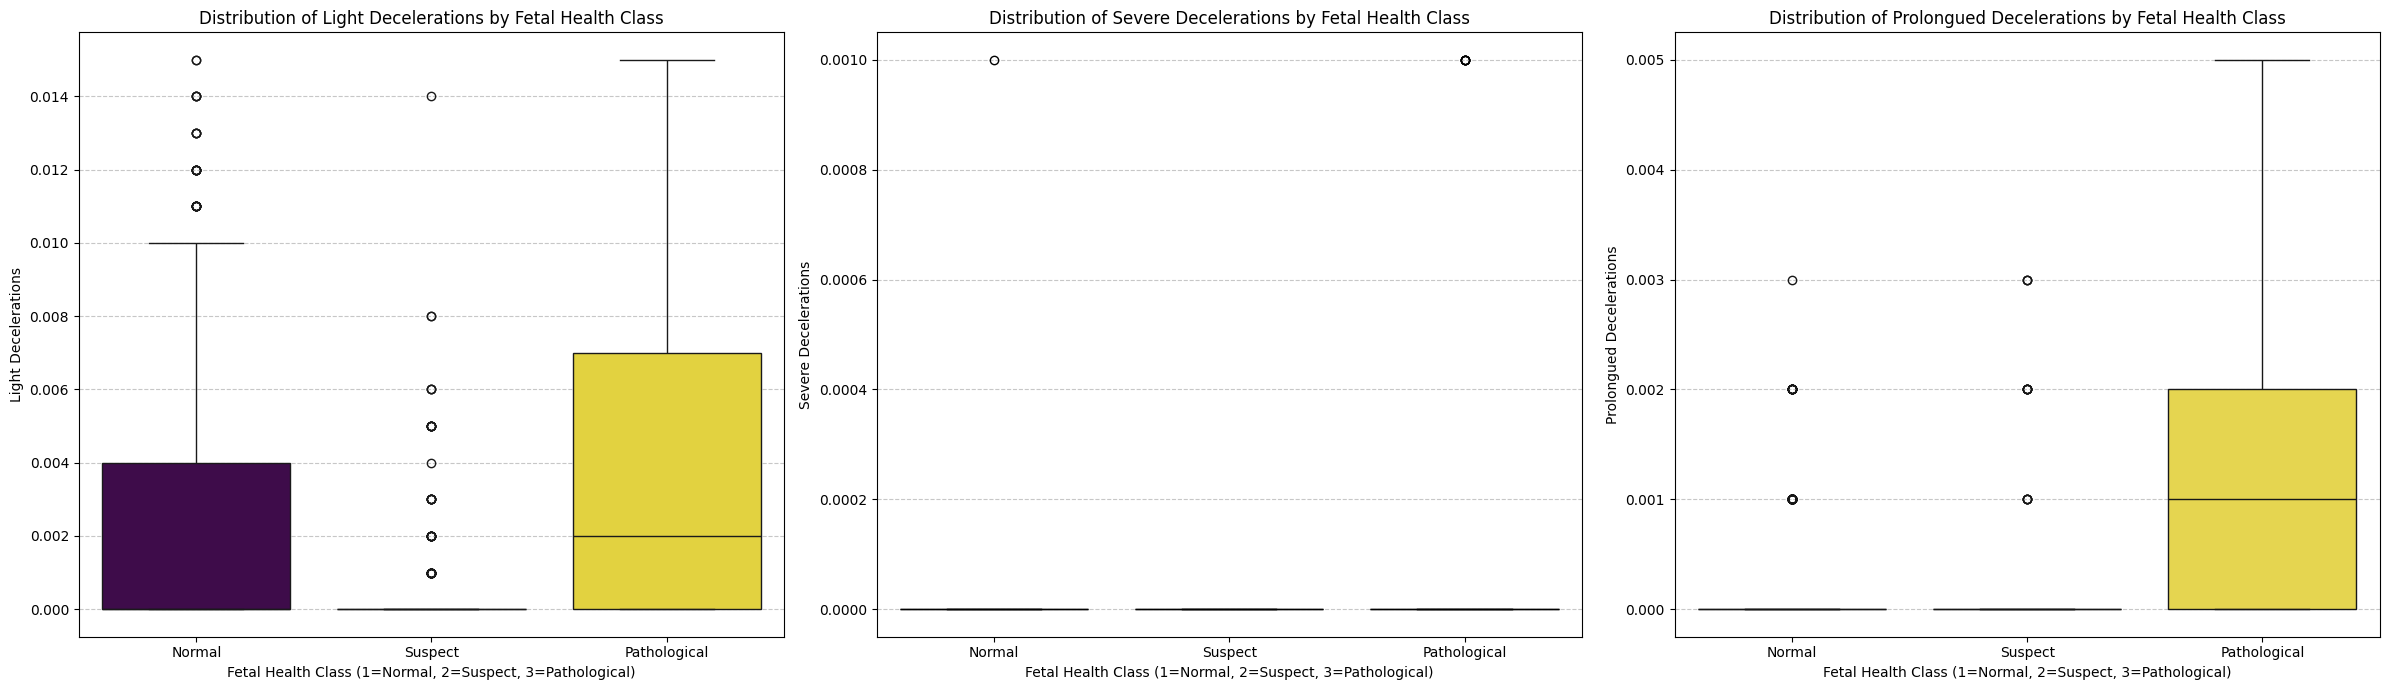

In [ ]:
light_decelerations_dist = fetal_data.groupby("fetal_health")["light_decelerations"].describe()
severe_decelerations_dist = fetal_data.groupby("fetal_health")["severe_decelerations"].describe()
prolongued_decelerations_dist = fetal_data.groupby("fetal_health")["prolongued_decelerations"].describe()
display(light_decelerations_dist)
display(severe_decelerations_dist)
display(prolongued_decelerations_dist)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.boxplot(data=fetal_data, x="fetal_health", y="light_decelerations", palette="viridis", hue="fetal_health", legend=False, ax=axes[0])
axes[0].set_title("Distribution of Light Decelerations by Fetal Health Class")
axes[0].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0].set_ylabel("Light Decelerations")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

sns.boxplot(data=fetal_data, x="fetal_health", y="severe_decelerations", palette="magma", hue="fetal_health", legend=False, ax=axes[1])
axes[1].set_title("Distribution of Severe Decelerations by Fetal Health Class")
axes[1].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[1].set_ylabel("Severe Decelerations")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

sns.boxplot(data=fetal_data, x="fetal_health", y="prolongued_decelerations", palette="cividis", hue="fetal_health", legend=False, ax=axes[2])
axes[2].set_title("Distribution of Prolongued Decelerations by Fetal Health Class")
axes[2].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[2].set_ylabel("Prolongued Decelerations")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

plt.tight_layout()
plt.show()

#### Findings

  Light Decelerations: Present in Normal and Pathological cases, with very low occurrences in Suspect cases.

   Severe Decelerations: Extremely rare across all fetal health classes.

   Prolonged Decelerations: Notably higher in Pathological cases compared to Normal and Suspect.

###4.3.4 Fetal Heart Rate Variability

a. Does abnormal short-term variability differ across classes?

b. Does mean short-term variability differ across classes?

c. Does the percentage of abnormal long-term variability differ across classes?

d. Does mean long-term variability differ across classes

,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,42.465861,15.497354,12.0,29.0,41.0,56.00,83.0
2.0,295.0,61.901695,11.761252,18.0,58.0,63.0,69.50,79.0
3.0,176.0,64.539773,14.452231,18.0,61.0,65.0,73.25,87.0


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,1.430634,0.818955,0.2,0.8,1.3,1.75,7.0
2.0,295.0,0.638983,0.661018,0.2,0.4,0.4,0.60,6.3
3.0,176.0,1.575568,1.199393,0.2,0.3,1.7,2.50,6.3


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,5.044713,11.526078,0.0,0.0,0.0,4.00,73.0
2.0,295.0,29.030508,20.265309,0.0,11.0,27.0,45.00,68.0
3.0,176.0,22.846591,33.995702,0.0,0.0,0.0,64.75,91.0


,count,mean,std,min,25%,50%,75%,max
fetal_health,,,,,,,,
1.0,1655.0,8.705498,5.822163,0.0,4.85,8.00,11.5,50.7
2.0,295.0,8.026102,3.753986,0.0,5.60,7.10,9.8,29.5
3.0,176.0,3.588636,4.091886,0.0,0.00,3.25,5.8,21.5


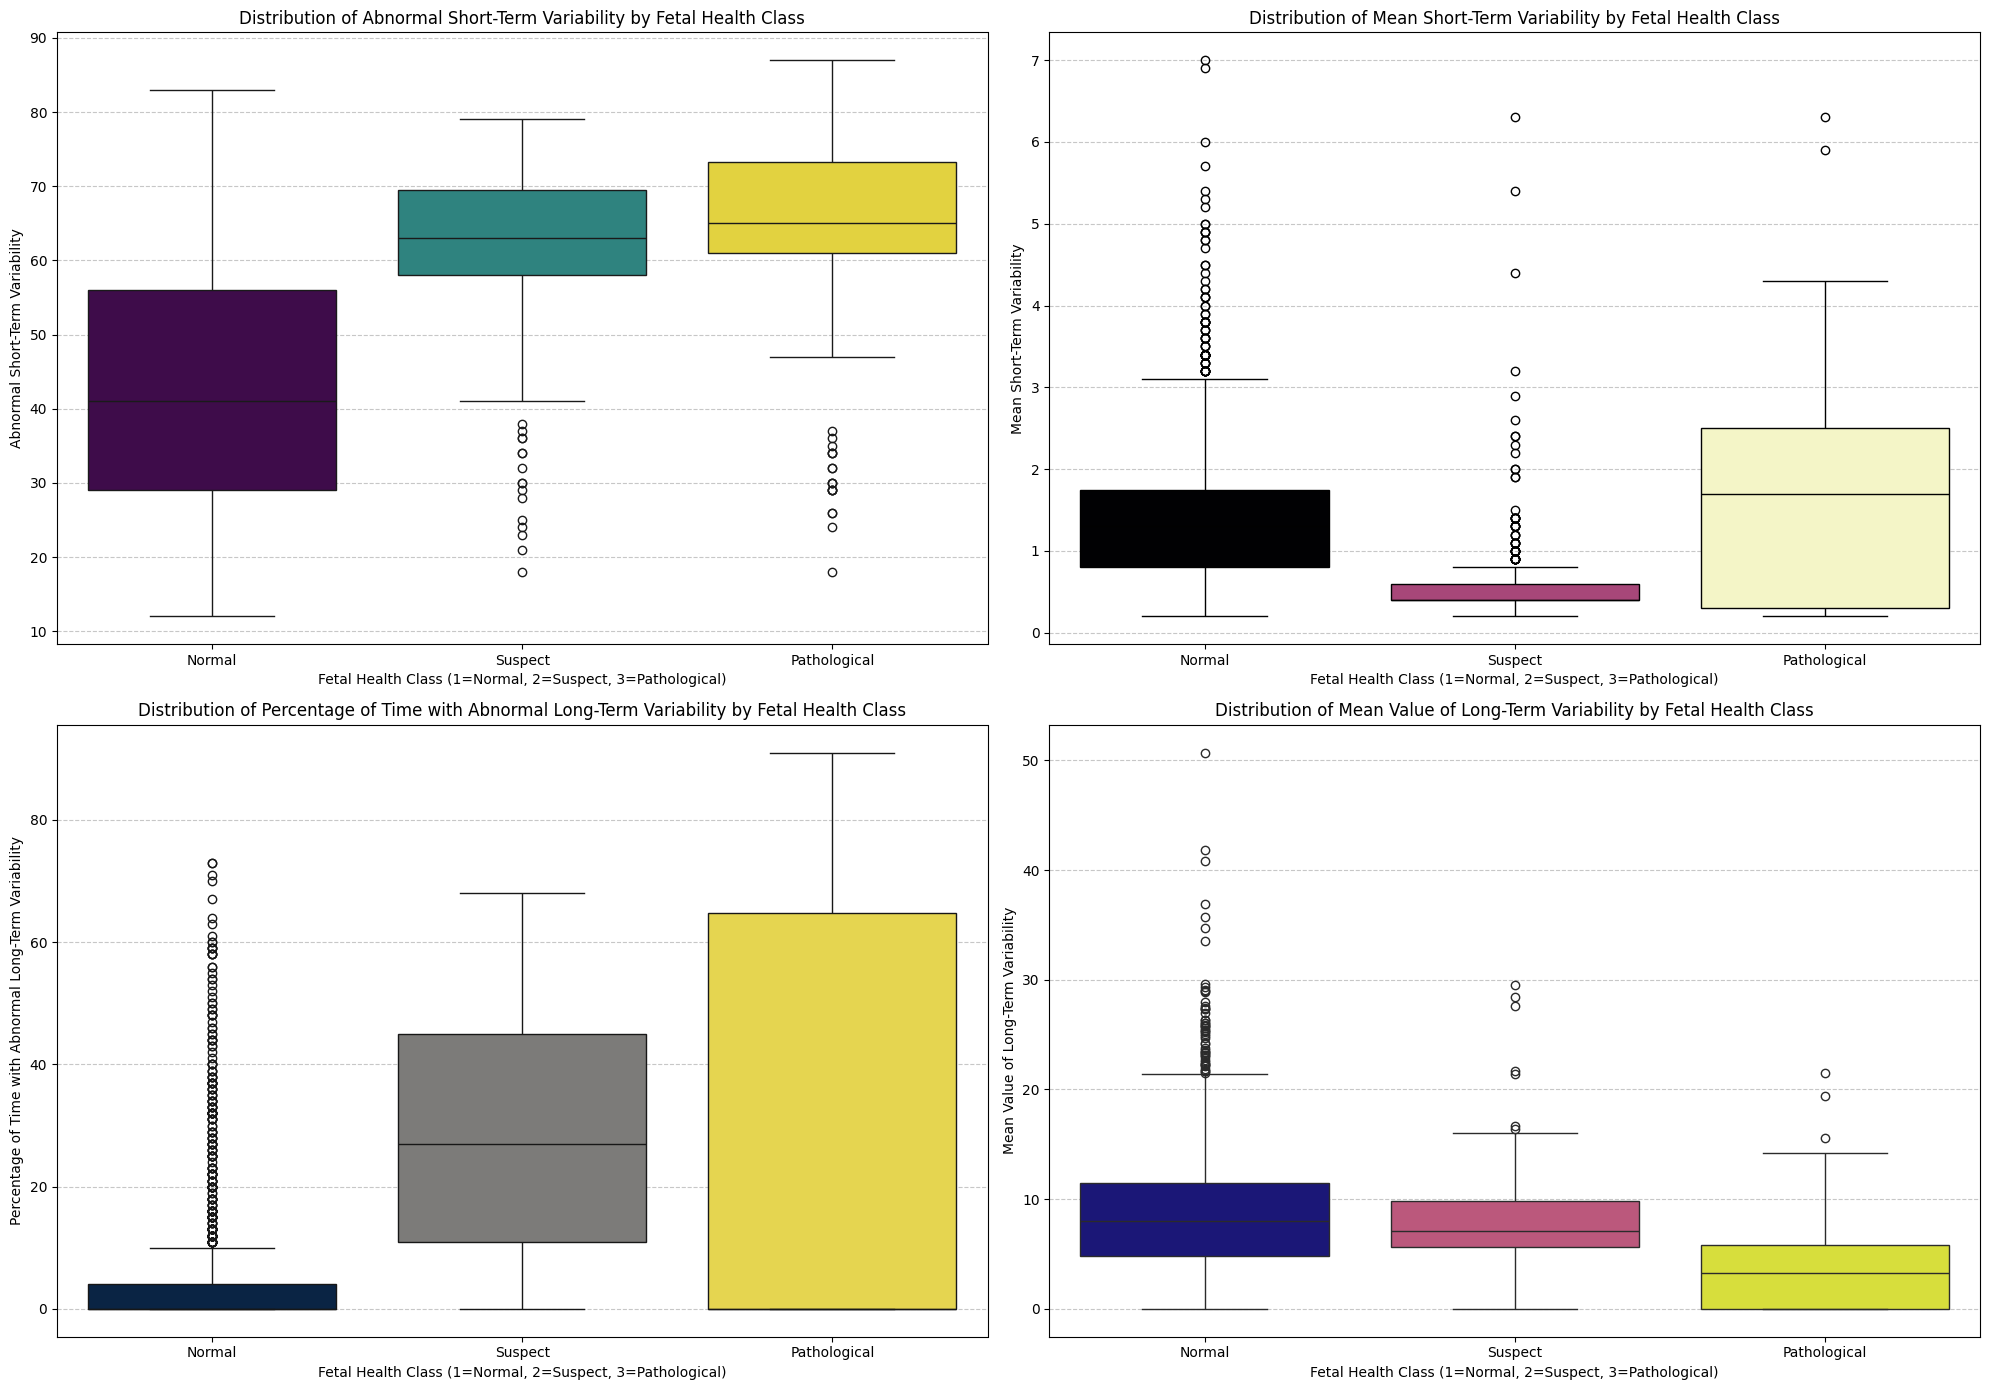

In [ ]:
abnormal_short_term_variability_dist = fetal_data.groupby("fetal_health")["abnormal_short_term_variability"].describe()
mean_value_of_short_term_variability_dist = fetal_data.groupby("fetal_health")["mean_value_of_short_term_variability"].describe()
percentage_of_time_with_abnormal_long_term_variability_dist = fetal_data.groupby("fetal_health")["percentage_of_time_with_abnormal_long_term_variability"].describe()
mean_value_of_long_term_variability_dist = fetal_data.groupby("fetal_health")["mean_value_of_long_term_variability"].describe()

display(abnormal_short_term_variability_dist)
display(mean_value_of_short_term_variability_dist)
display(percentage_of_time_with_abnormal_long_term_variability_dist)
display(mean_value_of_long_term_variability_dist)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

sns.boxplot(data=fetal_data, x="fetal_health", y="abnormal_short_term_variability", palette="viridis", hue="fetal_health", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Abnormal Short-Term Variability by Fetal Health Class")
axes[0, 0].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0, 0].set_ylabel("Abnormal Short-Term Variability")
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 0].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

sns.boxplot(data=fetal_data, x="fetal_health", y="mean_value_of_short_term_variability", palette="magma", hue="fetal_health", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Mean Short-Term Variability by Fetal Health Class")
axes[0, 1].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0, 1].set_ylabel("Mean Short-Term Variability")
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
axes[0, 1].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

sns.boxplot(data=fetal_data, x="fetal_health", y="percentage_of_time_with_abnormal_long_term_variability", palette="cividis", hue="fetal_health", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Percentage of Time with Abnormal Long-Term Variability by Fetal Health Class")
axes[1, 0].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[1, 0].set_ylabel("Percentage of Time with Abnormal Long-Term Variability")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 0].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

sns.boxplot(data=fetal_data, x="fetal_health", y="mean_value_of_long_term_variability", palette="plasma", hue="fetal_health", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Mean Value of Long-Term Variability by Fetal Health Class")
axes[1, 1].set_xlabel("Fetal Health Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[1, 1].set_ylabel("Mean Value of Long-Term Variability")
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1, 1].set_xticks([0, 1, 2], ['Normal', 'Suspect', 'Pathological'])

plt.tight_layout()
plt.show()

####Findings

Abnormal Short-Term Variability: Increases with worsening fetal health (Normal < Suspect < Pathological)

Mean Short-Term Variability: Highest in Normal, lowest in Suspect, and intermediate in Pathological.

Abnormal Long-Term Variability (Percentage):Significantly higher in Suspect and Pathological cases.

Mean Long-Term Variability: Decreases consistently from Normal to Suspect to Pathological cases.

###4.4 Correlation Analysis

a. How are the features related to each other?

b. Which features have the strongest correlation with fetal_health?

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
baseline value,1.000000,-0.080560,-0.033436,-0.146373,-0.159032,-0.053518,-0.104597,0.305570,-0.279607,0.285630,...,0.361619,0.275110,-0.113933,-0.004745,0.708993,0.723121,0.789246,-0.133938,0.293503,0.148151
accelerations,-0.080560,1.000000,0.048235,0.089674,-0.108615,-0.043018,-0.127749,-0.279577,0.207170,-0.373943,...,-0.154286,0.394147,0.190452,-0.006147,0.243610,0.270334,0.272849,0.125704,0.028420,-0.364066
fetal_movement,-0.033436,0.048235,1.000000,-0.068779,0.049228,-0.010976,0.265922,-0.103715,0.121314,-0.074096,...,-0.153917,0.099853,0.164654,-0.017749,-0.061192,-0.089671,-0.072329,0.179340,-0.001541,0.088010
uterine_contractions,-0.146373,0.089674,-0.068779,1.000000,0.285079,0.006788,0.077036,-0.232811,0.289679,-0.306608,...,-0.113323,0.122766,0.082693,0.057894,-0.104854,-0.187505,-0.140287,0.238582,-0.072314,-0.204894
light_decelerations,-0.159032,-0.108615,0.049228,0.285079,1.000000,0.107573,0.225611,-0.119152,0.562170,-0.271282,...,-0.553534,0.218043,0.397620,0.235296,-0.347233,-0.527354,-0.388586,0.564289,0.000072,0.058870
severe_decelerations,-0.053518,-0.043018,-0.010976,0.006788,0.107573,1.000000,0.012395,0.033949,0.034130,-0.030770,...,-0.071974,-0.021135,0.007024,0.043441,-0.215161,-0.158673,-0.160451,0.136421,-0.070483,0.131934
prolongued_decelerations,-0.104597,-0.127749,0.265922,0.077036,0.225611,0.012395,1.000000,0.046226,0.267011,-0.137333,...,-0.276764,0.120221,0.222860,0.056423,-0.436416,-0.488663,-0.444778,0.503301,-0.215405,0.484859
abnormal_short_term_variability,0.305570,-0.279577,-0.103715,-0.232811,-0.119152,0.033949,0.046226,1.000000,-0.430705,0.459413,...,0.275378,-0.111806,-0.167561,-0.149296,0.058363,0.074554,0.119960,-0.146434,-0.005748,0.471191
mean_value_of_short_term_variability,-0.279607,0.207170,0.121314,0.289679,0.562170,0.034130,0.267011,-0.430705,1.000000,-0.470259,...,-0.622569,0.409072,0.501430,0.266183,-0.307586,-0.445401,-0.336109,0.555852,-0.066140,-0.103382
percentage_of_time_with_abnormal_long_term_variability,0.285630,-0.373943,-0.074096,-0.306608,-0.271282,-0.030770,-0.137333,0.459413,-0.470259,1.000000,...,0.422834,-0.283183,-0.279301,-0.121784,0.165211,0.222321,0.186480,-0.281536,0.042481,0.426146


,fetal_health
fetal_health,1.000000
prolongued_decelerations,0.484859
abnormal_short_term_variability,0.471191
percentage_of_time_with_abnormal_long_term_variability,0.426146
histogram_variance,0.206630
baseline value,0.148151
severe_decelerations,0.131934
fetal_movement,0.088010
histogram_min,0.063175
light_decelerations,0.058870


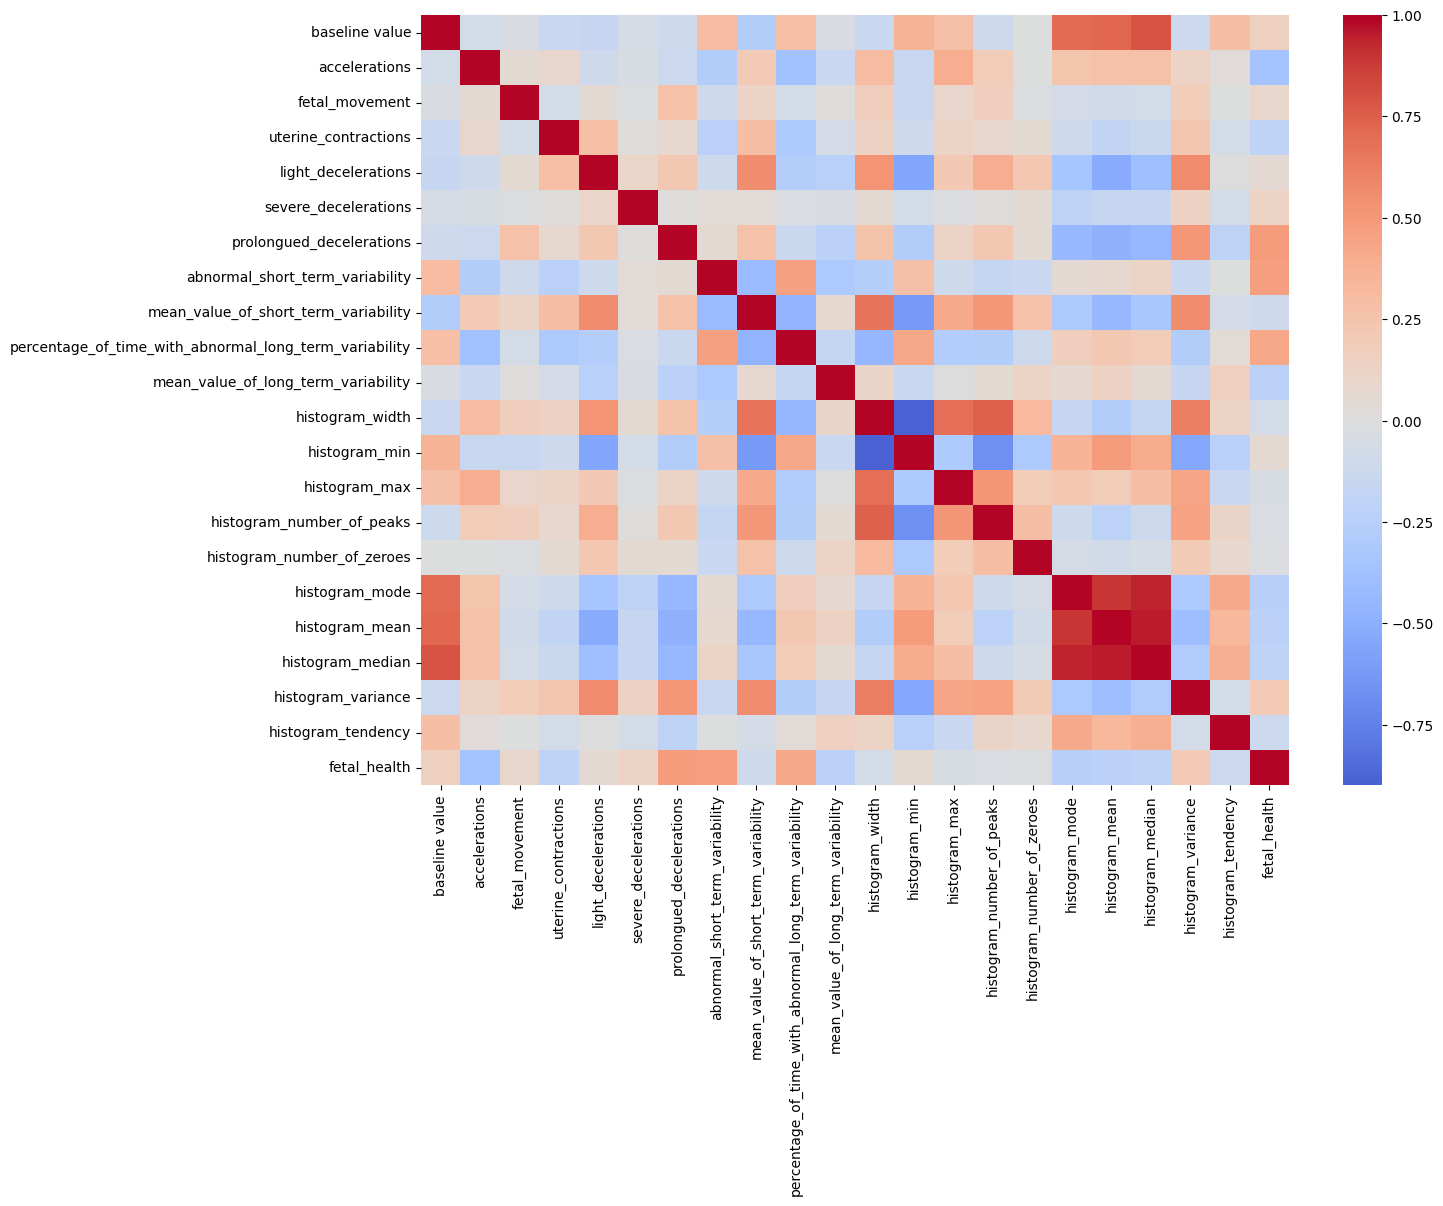

In [ ]:
correlation = fetal_data.corr()
corr_order = correlation["fetal_health"].sort_values(ascending=False)
display(correlation)
display(corr_order)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.show()

####Findings

 Strong Positive Correlation: prolongued_decelerations and abnormal_short_term_variability show the strongest positive correlation with fetal_health.

Strong Negative Correlation: mean_value_of_long_term_variability and accelerations have the strongest negative correlation with fetal_health.

Weak Correlation: severe_decelerations shows very weak correlation with fetal_health`
 and other features.

####Key EDA Findings


The dataset is highly imbalanced: 77.85% Normal, 13.88% Suspect, and a small Pathological minority — this will require careful model evaluation beyond raw accuracy.

Several CTG features show clear separation across fetal health classes, particularly abnormal short-term variability, prolonged decelerations, and light decelerations — these appear visually and statistically distinct between Normal and Pathological cases.

Fetal movement and uterine contraction patterns show weaker, noisier separation across classes.

Correlation analysis identified prolongued_decelerations and abnormal variability measures as most strongly associated with fetal_health, making them strong candidates for the model's most influential features.

Overall, CTG measurements carry meaningful signal for distinguishing fetal health status, but class imbalance means minority-class (Pathological) detection will be the real test of model quality — not overall accuracy.

##5. Data Preparation

In [ ]:
display(fetal_data.isnull().sum())
display("Duplicate rows:", fetal_data.duplicated().sum())
display(fetal_data['fetal_health'].unique())

duplicate_rows = fetal_data[fetal_data.duplicated(keep=False)].sort_values(by=list(fetal_data.columns))
display(duplicate_rows)

fetal_data = fetal_data.drop_duplicates().copy()
fetal_data['fetal_health'] = fetal_data['fetal_health'].astype(int)
display(fetal_data.shape)
display(fetal_data['fetal_health'].dtype)

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


'Duplicate rows:'

np.int64(13)

array([2., 1., 3.])

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
1112,122.0,0.000,0.000,0.000,0.0,0.0,0.0,19.0,1.9,0.0,...,103.0,142.0,1.0,0.0,120.0,120.0,122.0,3.0,0.0,1.0
1113,122.0,0.000,0.000,0.000,0.0,0.0,0.0,19.0,1.9,0.0,...,103.0,142.0,1.0,0.0,120.0,120.0,122.0,3.0,0.0,1.0
1114,122.0,0.000,0.000,0.000,0.0,0.0,0.0,19.0,1.9,0.0,...,103.0,142.0,1.0,0.0,120.0,120.0,122.0,3.0,0.0,1.0
1115,122.0,0.000,0.000,0.000,0.0,0.0,0.0,19.0,1.9,0.0,...,103.0,142.0,1.0,0.0,120.0,120.0,122.0,3.0,0.0,1.0
233,123.0,0.000,0.000,0.000,0.0,0.0,0.0,49.0,0.8,7.0,...,63.0,137.0,2.0,0.0,129.0,127.0,129.0,2.0,1.0,1.0
234,123.0,0.000,0.000,0.000,0.0,0.0,0.0,49.0,0.8,7.0,...,63.0,137.0,2.0,0.0,129.0,127.0,129.0,2.0,1.0,1.0
229,123.0,0.003,0.003,0.000,0.0,0.0,0.0,52.0,0.8,2.0,...,50.0,140.0,7.0,0.0,129.0,128.0,130.0,4.0,1.0,1.0
787,123.0,0.003,0.003,0.000,0.0,0.0,0.0,52.0,0.8,2.0,...,50.0,140.0,7.0,0.0,129.0,128.0,130.0,4.0,1.0,1.0
790,123.0,0.003,0.004,0.000,0.0,0.0,0.0,50.0,0.9,4.0,...,58.0,140.0,7.0,0.0,129.0,128.0,130.0,5.0,1.0,1.0
791,123.0,0.003,0.004,0.000,0.0,0.0,0.0,50.0,0.9,4.0,...,58.0,140.0,7.0,0.0,129.0,128.0,130.0,5.0,1.0,1.0


(2113, 22)

dtype('int64')

####Findings

13 duplicate rows were identified and removed to prevent repeated observations from disproportionately influencing the analysis and model.

##6. Data Preprocessing

In [ ]:
X = fetal_data.drop(columns = "fetal_health")
y = fetal_data["fetal_health"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)
display(y_train.value_counts())
display(y_test.value_counts())

display(X_train.describe().T)
display(X.dtypes)

(1690, 21)

(423, 21)

(1690,)

(423,)

,count
fetal_health,
1,1316
2,234
3,140


,count
fetal_health,
1,330
2,58
3,35


,count,mean,std,min,25%,50%,75%,max
baseline value,1690.0,133.192308,9.818739,106.0,126.000,133.000,140.000,160.000
accelerations,1690.0,0.003189,0.003881,0.0,0.000,0.002,0.006,0.019
fetal_movement,1690.0,0.010006,0.048304,0.0,0.000,0.000,0.003,0.481
uterine_contractions,1690.0,0.004359,0.002921,0.0,0.002,0.004,0.007,0.015
light_decelerations,1690.0,0.001828,0.002860,0.0,0.000,0.000,0.003,0.015
severe_decelerations,1690.0,0.000004,0.000064,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,1690.0,0.000170,0.000621,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,1690.0,46.781065,17.318200,12.0,32.000,48.000,61.000,87.000
mean_value_of_short_term_variability,1690.0,1.331775,0.881164,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,1690.0,9.887574,18.216165,0.0,0.000,0.000,11.000,91.000


,0
baseline value,float64
accelerations,float64
fetal_movement,float64
uterine_contractions,float64
light_decelerations,float64
severe_decelerations,float64
prolongued_decelerations,float64
abnormal_short_term_variability,float64
mean_value_of_short_term_variability,float64
percentage_of_time_with_abnormal_long_term_variability,float64


####Findings

All predictor variables are numerical ("float64"), so no categorical encoding was required.

The data was split into training and testing sets using stratification to preserve the class distribution.

Feature scaling was not applied because the selected models (Decision Tree, Random Forest, and XGBoost) are tree-based and do not require scaled features.

##7. Feature Engineering

###7.1 Feature-Target Relationship

In [ ]:
def make_mi_scores(X, y):
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_scores = pd.Series(mi_scores, index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X_train, y_train)
display(mi_scores)

,0
mean_value_of_short_term_variability,0.217423
abnormal_short_term_variability,0.202993
percentage_of_time_with_abnormal_long_term_variability,0.186288
histogram_mean,0.163013
histogram_variance,0.156491
histogram_median,0.148096
histogram_mode,0.139076
histogram_min,0.135109
histogram_width,0.131368
baseline value,0.128188


####Findings

This analysis examines how individual CTG features are related to the fetal health classification and identifies features that may contain useful predictive information.

The top five features which has been discovered to have the strongest relationship individually with the target are mean_value_of_short_term_variability,abnormal_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,
histogram_mean and histogram_variance.

###7.2 Relationship Visualization.

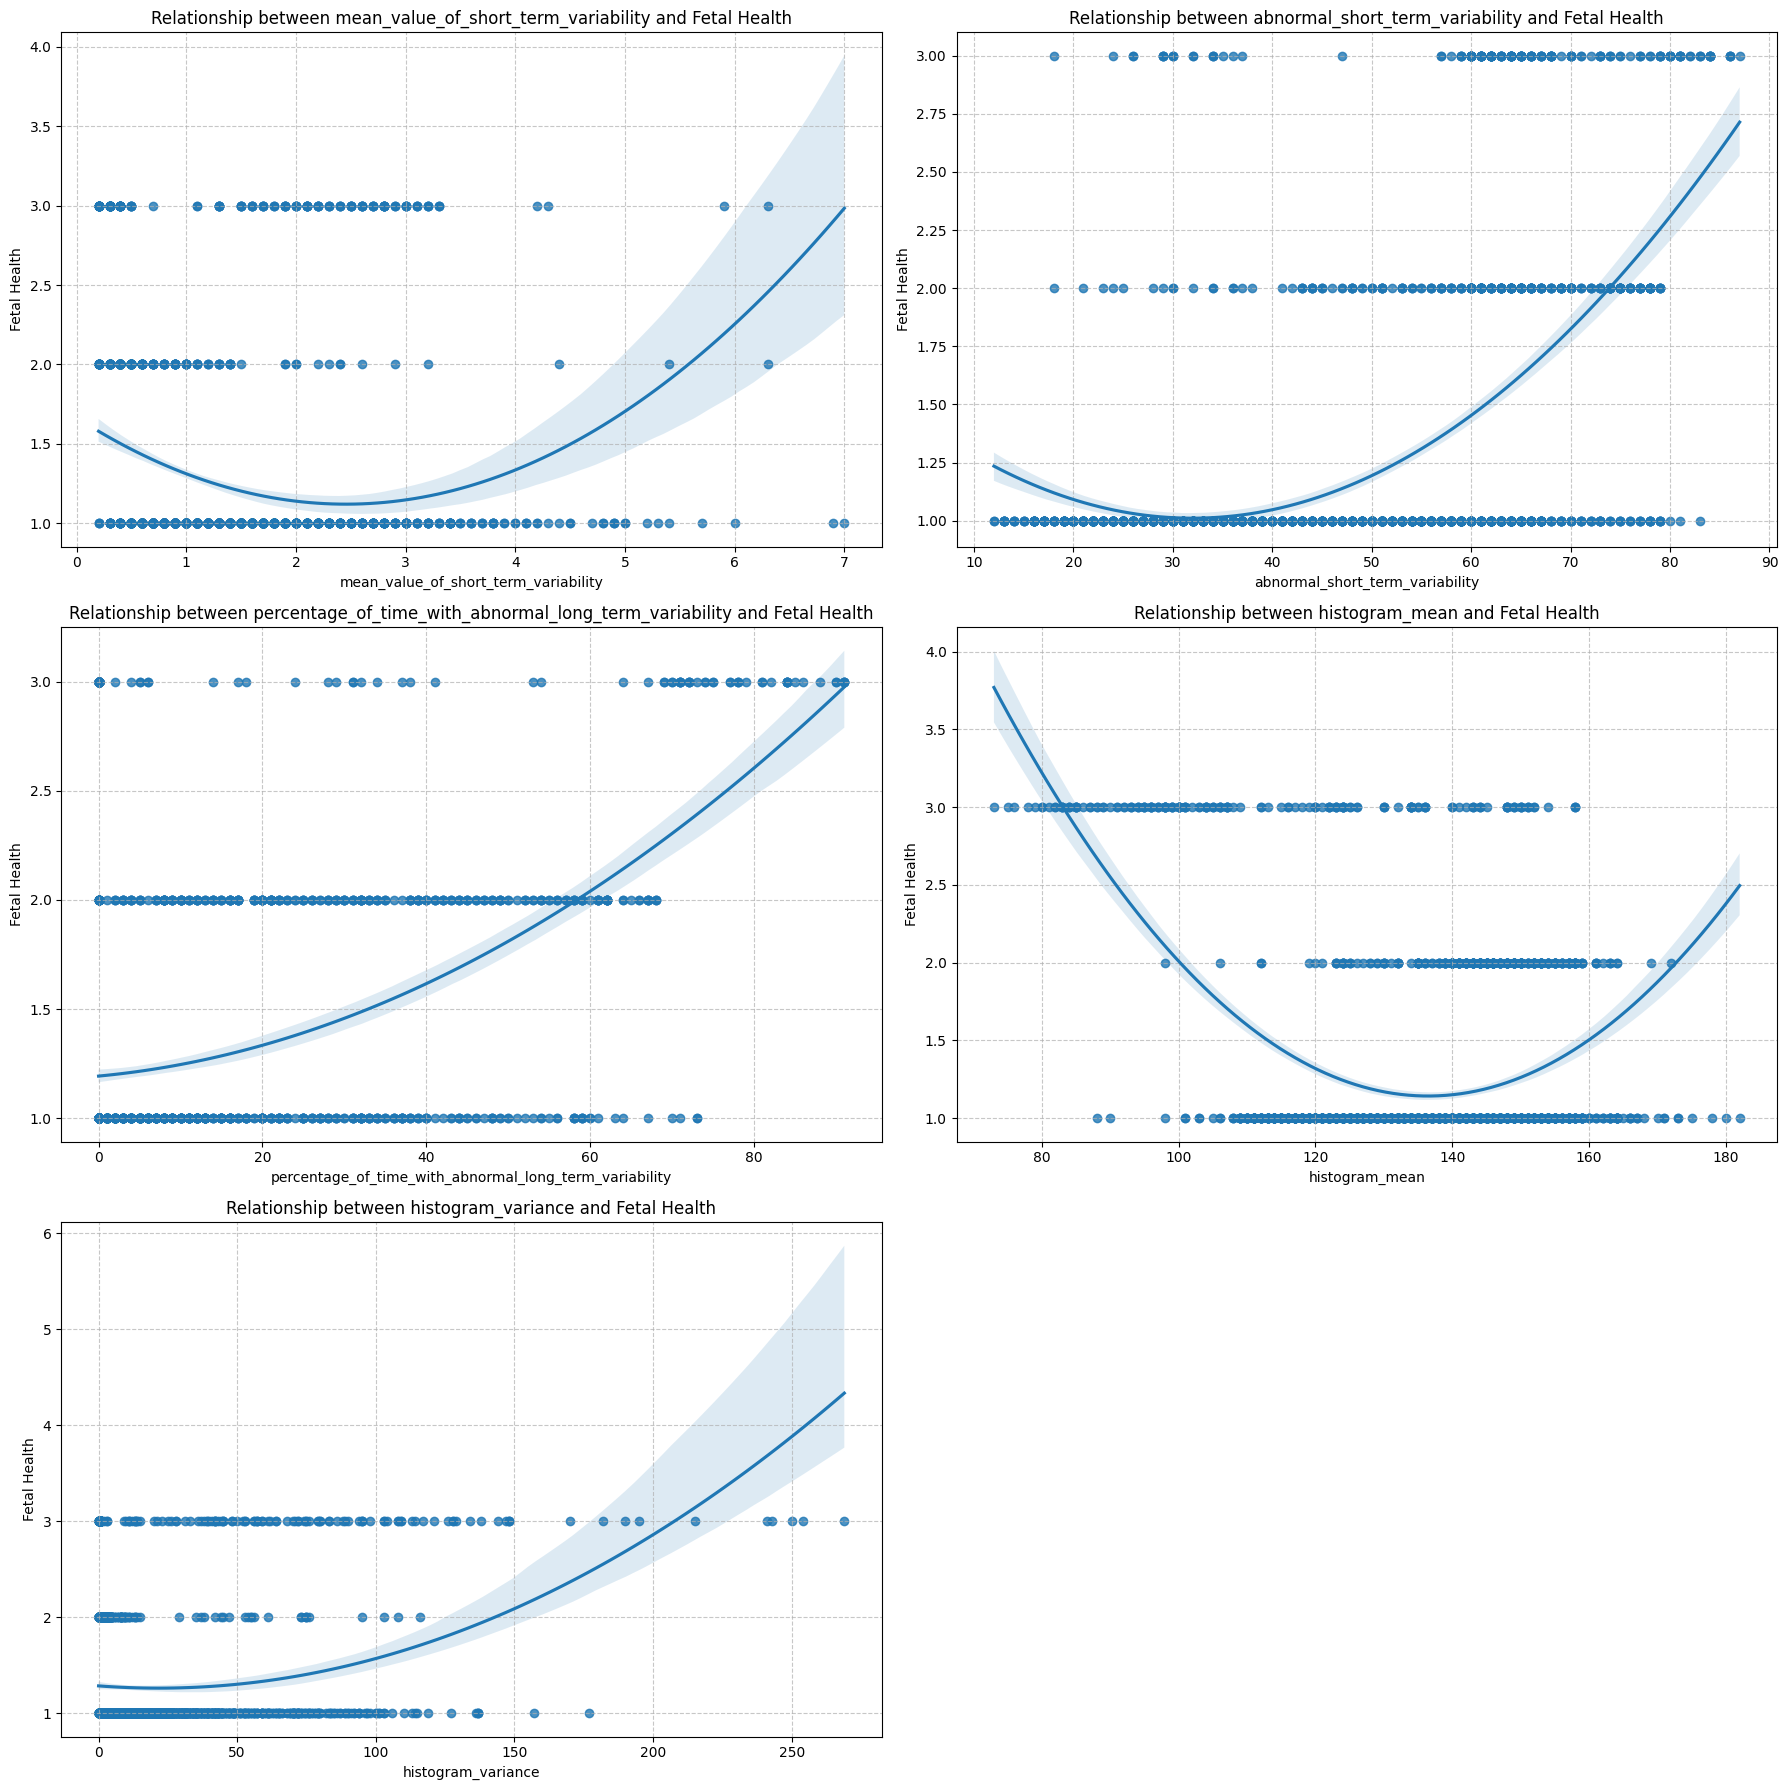

In [ ]:
top_5_features = mi_scores.head(5).index

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

axes = axes.flatten()

for i, feature in enumerate(top_5_features):
    sns.regplot(
        data=fetal_data,
        x=feature,
        y="fetal_health",
        order=2,
        ax=axes[i]
    )
    axes[i].set_title(f"Relationship between {feature} and Fetal Health")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Fetal Health")
    axes[i].grid(True, linestyle='--', alpha=0.7)

if len(top_5_features) < len(axes):
    for j in range(len(top_5_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

####Findings

The visualization of the top 5 features reveals distinct relationships with fetal health:
mean_value_of_short_term_variability  and histogram_mean show a parabolic or U-shaped relationship, where both very low and very high values are associated with higher fetal health classes (Suspect or Pathological), while moderate values correspond to normal health.
  abnormal_short_term_variability, percentage_of_time_with_abnormal_long_term_variability, and histogram_variance all exhibit a positive correlation, indicating that higher values in these features tend to be associated with an increased likelihood of Suspect or Pathological fetal health.

##8. Model Development

In [ ]:
baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train, y_train)
y_base_preds = baseline_model.predict(X_test)
print(classification_report(y_test, y_base_preds, zero_division=1))

              precision    recall  f1-score   support

           1       0.78      1.00      0.88       330
           2       1.00      0.00      0.00        58
           3       1.00      0.00      0.00        35

    accuracy                           0.78       423
   macro avg       0.93      0.33      0.29       423
weighted avg       0.83      0.78      0.68       423



####Findings

The Dummy Classifier achieved 78% accuracy by always predicting the majority class (Class 1).

However, it completely failed to identify Classes 2 and 3, with 0% recall and F1-score for both classes. This demonstrates that accuracy alone is misleading due to the class imbalance and provides a baseline for evaluating more advanced models.

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_dt_preds = dt_model.predict(X_test)
print(classification_report(y_test, y_dt_preds))
print(confusion_matrix(y_test, y_dt_preds))

              precision    recall  f1-score   support

           1       0.96      0.97      0.96       330
           2       0.80      0.76      0.78        58
           3       0.94      0.89      0.91        35

    accuracy                           0.93       423
   macro avg       0.90      0.87      0.88       423
weighted avg       0.93      0.93      0.93       423

[[320  10   0]
 [ 12  44   2]
 [  3   1  31]]


####Findings

The Decision Tree achieved 93% accuracy, substantially outperforming the Dummy Classifier. Unlike the baseline, it successfully identified all three fetal health classes, achieving recall scores of 97%, 76%, and 89% for Classes 1, 2, and 3 respectively.

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)
y_rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, y_rf_preds))
print(confusion_matrix(y_test, y_rf_preds))

              precision    recall  f1-score   support

           1       0.95      1.00      0.97       330
           2       0.93      0.72      0.82        58
           3       0.97      0.91      0.94        35

    accuracy                           0.95       423
   macro avg       0.95      0.88      0.91       423
weighted avg       0.95      0.95      0.95       423

[[329   1   0]
 [ 15  42   1]
 [  1   2  32]]


####Findings

The Random Forest achieved 95% accuracy and improved performance for Classes 1 and 3 compared with the Decision Tree. However, Class 2 recall decreased from 76% to 72%, indicating that the model identified fewer Class 2 cases despite achieving higher precision. Overall, Random Forest provided strong and balanced classification performance.

In [ ]:
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train - 1)
y_pred_xgb = xgb_model.predict(X_test) + 1
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           1       0.96      0.99      0.98       330
           2       0.94      0.79      0.86        58
           3       1.00      0.97      0.99        35

    accuracy                           0.96       423
   macro avg       0.97      0.92      0.94       423
weighted avg       0.96      0.96      0.96       423

[[328   2   0]
 [ 12  46   0]
 [  0   1  34]]


####Findings

XGBoost achieved the highest overall performance, with 96% accuracy and a macro F1-score of 94%. It demonstrated strong performance across all three classes, with recall of 99% for Class 1, 79% for Class 2, and 97% for Class 3. This represents an improvement over both the Decision Tree and Random Forest, particularly in identifying the minority classes.

##9. Model Evaluation and Comparison.

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


dt_accuracy = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

dt_f1 = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1_macro"
)

print("Decision Tree")
print("Accuracy scores:", dt_accuracy)
print("Mean Accuracy:", dt_accuracy.mean())
print("F1 Macro scores:", dt_f1)
print("Mean F1 Macro:", dt_f1.mean())


rf_accuracy = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

rf_f1 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1_macro"
)

print("\nRandom Forest")
print("Accuracy scores:", rf_accuracy)
print("Mean Accuracy:", rf_accuracy.mean())
print("F1 Macro scores:", rf_f1)
print("Mean F1 Macro:", rf_f1.mean())



xgb_accuracy = cross_val_score(
    xgb_model,
    X_train,
    y_train - 1,
    cv=skf,
    scoring="accuracy"
)

xgb_f1 = cross_val_score(
    xgb_model,
    X_train,
    y_train - 1,
    cv=skf,
    scoring="f1_macro"
)

print("\nXGBoost")
print("Accuracy scores:", xgb_accuracy)
print("Mean Accuracy:", xgb_accuracy.mean())
print("F1 Macro scores:", xgb_f1)
print("Mean F1 Macro:", xgb_f1.mean())

Decision Tree
Accuracy scores: [0.91420118 0.92011834 0.89349112 0.9408284  0.9112426 ]
Mean Accuracy: 0.9159763313609467
F1 Macro scores: [0.83657937 0.87349102 0.8182011  0.90309505 0.84017932]
Mean F1 Macro: 0.8543091721018421

Random Forest
Accuracy scores: [0.93491124 0.94378698 0.91715976 0.94378698 0.9408284 ]
Mean Accuracy: 0.9360946745562131
F1 Macro scores: [0.86857949 0.8858186  0.85300495 0.90919374 0.88993389]
Mean F1 Macro: 0.8813061330940926

XGBoost
Accuracy scores: [0.93195266 0.94970414 0.93491124 0.95266272 0.93786982]
Mean Accuracy: 0.9414201183431953
F1 Macro scores: [0.86860149 0.90979233 0.88084249 0.92245542 0.88537473]
Mean F1 Macro: 0.8934132931514236


####Findings

Cross-validation confirmed that XGBoost was the strongest-performing model, achieving the highest mean accuracy (94.14%) and macro F1-score (0.893) across the five folds. Random Forest followed with a mean accuracy of 93.61% and macro F1-score of 0.881, while the Decision Tree recorded 91.60% accuracy and 0.854 macro F1-score. XGBoost also showed relatively consistent performance across the folds, supporting its selection as the leading model for further hyperparameter tuning.

##10. Hyperparameter Tuning

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5]
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro"
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    refit="f1_macro",
    n_jobs=-1
)


grid_search.fit(X_train, y_train - 1)


print("Best parameters:")
print(grid_search.best_params_)


print("Best CV F1-macro:")
print(grid_search.best_score_)

best_index = grid_search.best_index_

print("CV Accuracy for best configuration:")
print(grid_search.cv_results_["mean_test_accuracy"][best_index])

Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV F1-macro:
0.8976999695378212
CV Accuracy for best configuration:
0.9437869822485208


####Findings

Hyperparameter tuning identified an XGBoost configuration with a learning rate of 0.1, maximum tree depth of 3, and 200 estimators as the best-performing combination. Using 5-fold stratified cross-validation, the model achieved a mean macro F1-score of 89.8% and an average accuracy of 94.4%. This indicates strong and relatively balanced performance across the three fetal health classes.

##11. Model Configuration Testing

In [ ]:
xgb_tuned_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_tuned_model.fit(X_train, y_train - 1)
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test) + 1


print(classification_report(y_test, y_pred_xgb_tuned))
print(confusion_matrix(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           1       0.95      0.99      0.97       330
           2       0.96      0.74      0.83        58
           3       0.97      0.97      0.97        35

    accuracy                           0.96       423
   macro avg       0.96      0.90      0.93       423
weighted avg       0.96      0.96      0.95       423

[[327   2   1]
 [ 15  43   0]
 [  1   0  34]]


In [ ]:
tuned_accuracy_scores = cross_val_score(
    xgb_tuned_model,
    X_train,
    y_train - 1,
    cv=skf,
    scoring="accuracy"
)

print("Tuned XGBoost accuracy scores:", tuned_accuracy_scores)
print("Mean CV accuracy:", tuned_accuracy_scores.mean())



tuned_f1_scores = cross_val_score(
    xgb_tuned_model,
    X_train,
    y_train - 1,
    cv=skf,
    scoring="f1_macro"
)

print("Tuned XGBoost F1 scores:", tuned_f1_scores)
print("Mean CV F1:", tuned_f1_scores.mean())

Tuned XGBoost accuracy scores: [0.93491124 0.95266272 0.93195266 0.9556213  0.94378698]
Mean CV accuracy: 0.9437869822485208
Tuned XGBoost F1 scores: [0.87034975 0.91582359 0.87497923 0.92559941 0.90174787]
Mean CV F1: 0.8976999695378212


The tuned XGBoost model achieved a mean cross-validation accuracy of 94.38% and a mean macro F1-score of 89.77% across five folds. Compared with the untuned model, performance improved slightly in both accuracy (94.14% → 94.38%) and macro F1 (89.34% → 89.77%), indicating a small but consistent improvement in overall and balanced classification performance.

##12. Final Model Selection

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Decision Tree",
        "Random Forest",
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "Test Accuracy": [
        0.78,
        0.93,
        0.95,
        0.96,
        0.96
    ],
    "Test Macro F1": [
        0.29,
        0.88,
        0.91,
        0.94,
        0.93
    ],
    "CV Accuracy": [
        None,
        None,
        None,
        0.9414,
        0.9438
    ],
    "CV Macro F1": [
        None,
        None,
        None,
        0.8934,
        0.8977
    ]
})

model_comparison

,Model,Test Accuracy,Test Macro F1,CV Accuracy,CV Macro F1
0,Dummy Classifier,0.78,0.29,NaN,NaN
1,Decision Tree,0.93,0.88,NaN,NaN
2,Random Forest,0.95,0.91,NaN,NaN
3,Original XGBoost,0.96,0.94,0.9414,0.8934
4,Tuned XGBoost,0.96,0.93,0.9438,0.8977


####Findings and Decisions

Based on the evaluation results, Original XGBoost was selected as the final model. It achieved the highest test accuracy (96%) and Macro F1-score (0.94), outperforming the Decision Tree and Random Forest. Although the tuned XGBoost showed a slight improvement in cross-validation performance, it achieved a lower test Macro F1-score (0.93) and lower recall for Class 2 (74% vs. 79%). Therefore, the original XGBoost provided the best overall balance of accuracy and performance across the three fetal health classes.

##13. Feature Importance

                                              Feature  Importance
8                mean_value_of_short_term_variability    0.151498
6                            prolongued_decelerations    0.143603
17                                     histogram_mean    0.138977
1                                       accelerations    0.107786
7                     abnormal_short_term_variability    0.095805
9   percentage_of_time_with_abnormal_long_term_var...    0.083985
14                          histogram_number_of_peaks    0.036738
16                                     histogram_mode    0.036002
18                                   histogram_median    0.031690
3                                uterine_contractions    0.025414
0                                      baseline value    0.025036
13                                      histogram_max    0.023548
12                                      histogram_min    0.021162
4                                 light_decelerations    0.020730
2         

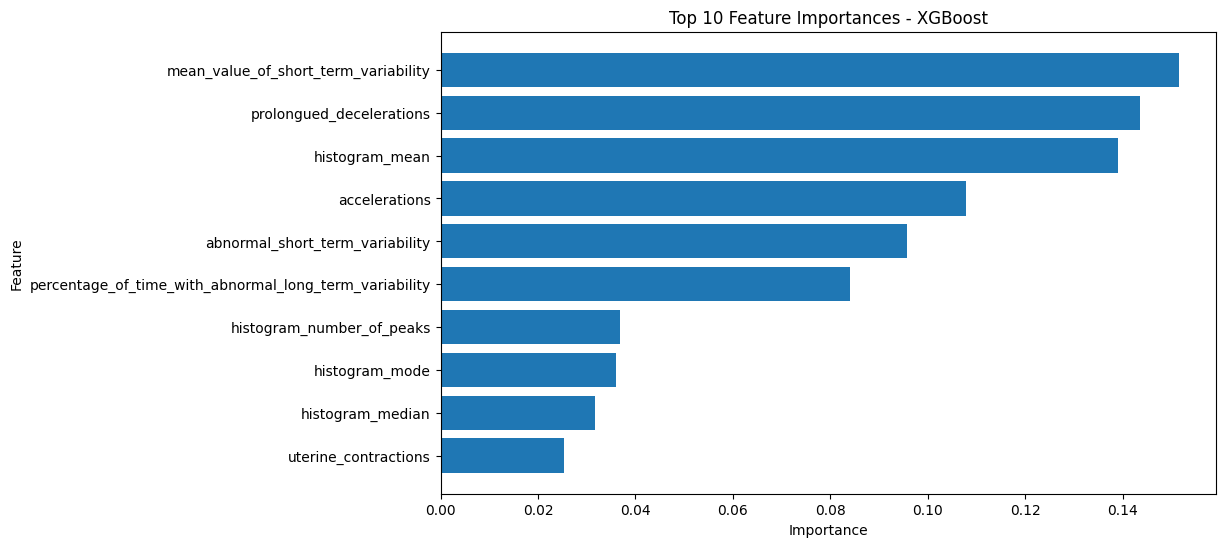

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - XGBoost")
plt.gca().invert_yaxis()

plt.show()

####Findings

The feature importance analysis for the XGBoost model reveals that mean_value_of_short_term_variability, prolongued_decelerations, histogram_mean, and accelerations are the most influential features in predicting fetal health status. This highlights the critical role of heart rate variability and deceleration patterns in the model's decision-making process.

##Final Model Summary


The Original XGBoost classifier was selected as the final model based on its overall performance. It achieved 96% accuracy and a Macro F1-score of 0.94 on the test set. The model also demonstrated strong recall across all three fetal health classes, with 99% for Class 1, 79% for Class 2, and 97% for Class 3. Cross-validation further showed consistent performance, with a mean accuracy of 94.14% and a mean Macro F1-score of 89.34%.

##Conclusion



This project developed a machine learning model for fetal health classification using cardiotocography (CTG) measurements. Exploratory analysis and feature investigation identified important patterns in the CTG data, while several classification algorithms were evaluated. XGBoost achieved the best overall performance, reaching 96% test accuracy and a 0.94 Macro F1-score. The results demonstrate the potential of machine learning to assist in identifying different fetal health conditions from CTG measurements. However, the model would require further validation on diverse clinical data and proper clinical evaluation before it could be considered for real-world healthcare use